In [1]:
import os
import sys
import numpy as np
import xarray as xr

In [2]:
import dask
import zarr

In [3]:
sys.path.insert(0, os.path.realpath('../libs/'))
import plevel_utils as pu

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# fn_static = '/glade/campaign/collections/rda/data/d559000/INVARIANT/USGS404_geo_em_d01.nc'
# ds_static = xr.open_dataset(fn_static)
# elev_var = ds_static['VAR'].values

In [6]:
# fn_static = '/glade/campaign/collections/rda/data/d559000/INVARIANT/wrfconstants_usgs404.nc'
# ds_static = xr.open_dataset(fn_static)
# lu = ds_static['LU_INDEX'].values

In [7]:
# plt.pcolormesh(veg[0, ...])

In [8]:
fn_static = '/glade/campaign/collections/rda/data/d559000/INVARIANT/USGS404_geo_em_d01.nc'
ds_static = xr.open_dataset(fn_static)
ds_static = ds_static[['HGT_M', 'LANDMASK', 'VAR', 'XLONG_M', 'XLAT_M']]
ds_static = ds_static.rename({'XLONG_M': 'XLONG', 'XLAT_M': 'XLAT'})
ds_static = ds_static.squeeze(dim="Time")

data_elev = ds_static['HGT_M'].values
data_var = ds_static['VAR'].values

ds_static = ds_static.isel(west_east=slice(905, 1240+1, 1), south_north=slice(290, 625+1, 1))

ds_static['z_norm'] = (ds_static['HGT_M'] - np.mean(data_elev)) / np.std(data_elev)
ds_static['var_norm'] = (ds_static['VAR'] - np.mean(data_var)) / np.std(data_var)

In [9]:
fn_static_wrf = '/glade/campaign/collections/rda/data/d559000/INVARIANT/wrfconstants_usgs404.nc'
ds_static_wrf = xr.open_dataset(fn_static_wrf)

ds_static_wrf = ds_static_wrf[['LU_INDEX', 'LAKEMASK', 'XLONG', 'XLAT']]
ds_static_wrf = ds_static_wrf.squeeze(dim="Time")
ds_static_wrf = ds_static_wrf.reset_coords(drop=True)
ds_static_wrf = ds_static_wrf.isel(west_east=slice(905, 1240+1, 1), south_north=slice(290, 625+1, 1))
# lu = ds_static_wrf['LU_INDEX'].values
ds_static['lu_norm'] = ds_static_wrf['LU_INDEX'] / 17
ds_static['LAKEMASK'] = ds_static_wrf['LAKEMASK']

In [10]:
varnames = list(ds_static.keys())

# zarr encodings
dict_encoding = {}

chunk_size_2d = dict(chunks=(336, 336))

compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)

for i_var, var in enumerate(varnames):
    dict_encoding[var] = {'compressor': compress, **chunk_size_2d}

In [11]:
#

In [13]:
save_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_SW/static/C404_GP_static_SW.zarr'
# ds_static.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)

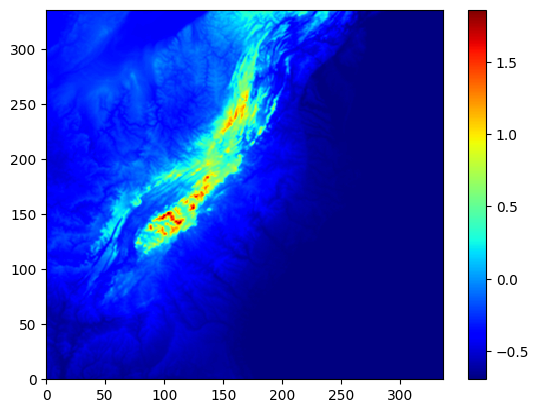

In [12]:
plt.pcolormesh(ds_static['z_norm'].values, cmap=plt.cm.jet)
plt.colorbar()

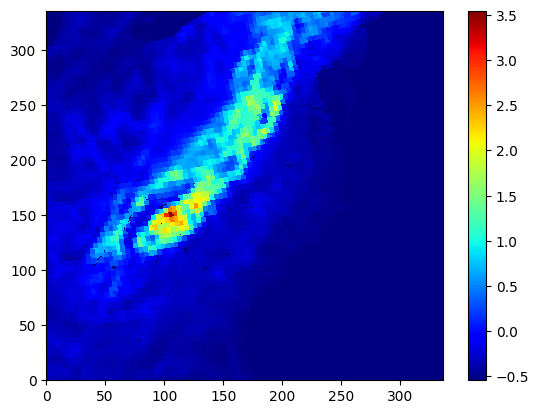

In [14]:
plt.pcolormesh(ds_static['var_norm'].values, cmap=plt.cm.jet)
plt.colorbar()

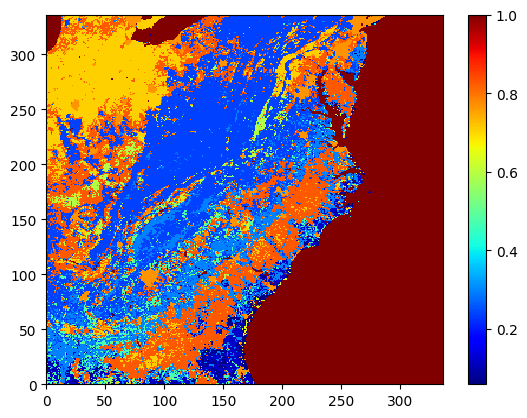

In [15]:
plt.pcolormesh(ds_static['lu_norm'].values, cmap=plt.cm.jet)
plt.colorbar()